# Cell Type Assignment from Marker Combinations

This notebook assigns cell types using a **three-step QC-first pipeline**:

1. **Quality control → remove artifacts** before any phenotyping  
2. **Phenotyping matrix** applied only to cells that pass QC  
3. **Summarize & visualize** — counts, bar plot, spatial overlay

---

## Three-Step Workflow

### Step 1 — Nucleus Check (QC gate)
> `DAPI−` → **Artifact_NoNucleus** (discard)

Cells lacking a detectable nucleus are Cellpose segmentation artifacts (e.g., debris or cell fragments that snuck into the mask). They must be removed before any marker interpretation.

### Step 2 — Impossible-Biology Checks (Spillover Gates)
> Mutually exclusive core lineage co-expression → **Artifact_Spillover** (discard / flag)

CellDIVE uses sequential staining with antibody stripping. Residual fluorophore bleed-through or incomplete stripping can cause a cell to appear positive for two markers that cannot biologically co-occur:

| Gate | Why it cannot happen |
|------|----------------------|
| CD45+ & PANCK+ | Leukocyte + Epithelial |
| CD45+ & CD31+  | Leukocyte + Endothelial |
| PANCK+ & CD31+ | Epithelial + Endothelial |
| CD3E+ & CD20+  | T-cell + B-cell |

**EMT exception — do NOT flag PANCK+ / VIM+:**  
In aggressive bladder cancer, epithelial tumour cells undergo Epithelial-Mesenchymal Transition (EMT).
These cells lose rigidity and become motile by actively co-expressing both PanCK (epithelial) and Vimentin (mesenchymal).
Flagging them as artifacts would silently delete the most invasive cells in the dataset.

### Step 3 — Phenotyping Matrix
Only cells that survive Steps 1 and 2 are passed through the full marker-combination gating logic
(`input/Cell Phenotyping Matrix.csv` rules).

---

## Inputs / Outputs

| | Path | Description |
|---|---|---|
| **In** | `output/celldive_protein_matrix.h5ad` | Cells × proteins; `layers["binary"]` used for gating |
| **Out** | `output/celldive_protein_matrix_celltypes.h5ad` | Adds `obs["cell_type"]`, `obs["qc_label"]`, `obs["is_clean"]` |

## 1. Imports

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import anndata as ad

## 2. Configuration

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
INPUT_H5AD = PROJECT_ROOT / "output" / "celldive_protein_matrix.h5ad"

# If X is continuous, use this percentile as positive threshold (e.g. 25 = values >= p25 → 1)
BINARY_THRESHOLD_PCT = 25

print(f"Input: {INPUT_H5AD}")

Input: /home/steve/Projects/HeLab/BladderDIVE/output/celldive_protein_matrix.h5ad


## 3. Load H5AD

In [3]:
adata = ad.read_h5ad(INPUT_H5AD)
print(f"Cells: {adata.n_obs}, Proteins: {adata.n_vars}")
print(f"var_names: {list(adata.var_names)}")
adata

Cells: 926006, Proteins: 23
var_names: ['DAPI', 'CD45', 'CD3E', 'Ki67', 'CD8a', 'VIM', 'CD68', 'HLADR', 'CD31', 'ACTA2', 'CD20', 'CD163', 'CD44', 'PANCK', 'CD38', 'CD11c', 'PDGFRA', 'COL1A1', 'CD14', 'EPCAM', 'CD56', 'CD45RO', 'DAPI2']


AnnData object with n_obs × n_vars = 926006 × 23
    obs: 'cell_id', 'area', 'centroid_x', 'centroid_y'
    uns: 'background_estimate', 'background_percentile', 'binary_threshold', 'binary_thresholds', 'data_source', 'sample_id'
    obsm: 'spatial'
    layers: 'binary'

## 4. Get binary matrix

Use `layers["binary"]` from the pipeline (recommended). If missing, fall back to binarizing X in memory.

In [4]:
# Prefer layers["binary"] from the protein matrix pipeline
if "binary" in adata.layers:
    X_bin = np.asarray(adata.layers["binary"], dtype=np.uint8)
    if hasattr(X_bin, "toarray"):
        X_bin = X_bin.toarray()
    print("Using adata.layers['binary'] for cell typing.")
else:
    # Fallback: binarize X in memory
    X = adata.X
    if hasattr(X, "toarray"):
        X = X.toarray()
    X = np.asarray(X, dtype=np.float32)
    unique_vals = np.unique(X)
    is_binary = len(unique_vals) <= 2 and set(unique_vals).issubset({0, 1})
    if is_binary:
        print("layers['binary'] missing. X is already binary (0/1). Using as-is.")
        X_bin = X.astype(np.uint8)
    else:
        print(f"layers['binary'] missing. Applying {BINARY_THRESHOLD_PCT}th percentile threshold per marker.")
        X_bin = np.zeros_like(X, dtype=np.uint8)
        for j in range(X.shape[1]):
            thresh = np.percentile(X[:, j], BINARY_THRESHOLD_PCT)
            X_bin[:, j] = (X[:, j] >= thresh).astype(np.uint8)

# Build lookup: marker_name -> column index
marker_to_col = {m: i for i, m in enumerate(adata.var_names)}

Using adata.layers['binary'] for cell typing.


## 5. Quality Control — Spillover Gates

Cells are already defined by **DAPI-based Cellpose** segmentation, so there is no DAPI
binary nucleus gate.  Spillover pairs are flagged as `Artifact_Spillover`; all other cells are
`Pass` and continue to phenotyping.

### Configurable spillover gates

Edit `SPILLOVER_GATES` below to add or remove pairs as your panel evolves.  Each entry is
`(marker_A, marker_B, reason_string)`.

### EMT exception
`PANCK` + `VIM` co-expression is **intentionally excluded** from the spillover list.
These double-positive cells are biologically valid EMT (Epithelial-Mesenchymal Transition) cells —
among the most invasive tumour cells in bladder cancer — and must not be discarded.


In [5]:
n_cells = X_bin.shape[0]

# ── Spillover gate configuration ─────────────────────────────────────────────
# Each tuple: (marker_A, marker_B, reason_label)
# Add / remove pairs here without touching the logic below.
# NOTE: PANCK + VIM is intentionally absent — EMT cells are biologically valid.
SPILLOVER_GATES: list[tuple[str, str, str]] = [
    ("CD45",  "PANCK", "Immune+Epithelial"),
    ("CD45",  "CD31",  "Immune+Endothelial"),
    ("PANCK", "CD31",  "Epithelial+Endothelial"),
    ("CD3E",  "CD20",  "TCell+BCell"),
]

# ── Step 1: Nucleus check — skipped ─────────────────────────────────────────
# Cells come from DAPI-based Cellpose masks; DAPI binary gating is not used.
qc_label = np.full(n_cells, "Pass", dtype=object)
print(
    "Step 1 — Nucleus check skipped: segmentation mask already defines nucleated cells "
    "(DAPI is not binarized for gating)."
)

# ── Step 2: Spillover gates ────────────────────────────────────────────────────
print("\nStep 2 — Spillover gates:")
n_spillover_total = 0
for m1, m2, reason in SPILLOVER_GATES:
    if m1 not in marker_to_col or m2 not in marker_to_col:
        print(f"  SKIP  {m1}+ & {m2}+  (marker missing from panel)")
        continue
    c1, c2 = marker_to_col[m1], marker_to_col[m2]
    mask = (X_bin[:, c1] == 1) & (X_bin[:, c2] == 1) & (qc_label == "Pass")
    n = int(mask.sum())
    n_spillover_total += n
    qc_label[mask] = "Artifact_Spillover"
    print(f"  FLAG  {m1}+ & {m2}+  → {n:,} cells  ({100 * n / n_cells:.2f} %)  [{reason}]")

# ── Summary ───────────────────────────────────────────────────────────────────
n_no_nucleus = int((qc_label == "Artifact_NoNucleus").sum())
n_spillover  = int((qc_label == "Artifact_Spillover").sum())
n_clean      = int((qc_label == "Pass").sum())
is_clean = qc_label == "Pass"

adata.obs["qc_label"] = pd.Categorical(qc_label)
adata.obs["is_clean"] = is_clean

print(f"\nQC summary:")
print(f"  Pass (clean)           : {n_clean:,}  ({100 * n_clean / n_cells:.2f} %)")
print(f"  Artifact_NoNucleus     : {n_no_nucleus:,}  ({100 * n_no_nucleus / n_cells:.2f} %)")
print(f"  Artifact_Spillover     : {n_spillover:,}  ({100 * n_spillover / n_cells:.2f} %)")


Step 1 — Nucleus check skipped: segmentation mask already defines nucleated cells (DAPI is not binarized for gating).

Step 2 — Spillover gates:
  FLAG  CD45+ & PANCK+  → 15,094 cells  (1.63 %)  [Immune+Epithelial]
  FLAG  CD45+ & CD31+  → 51,110 cells  (5.52 %)  [Immune+Endothelial]
  FLAG  PANCK+ & CD31+  → 2,547 cells  (0.28 %)  [Epithelial+Endothelial]
  FLAG  CD3E+ & CD20+  → 77,833 cells  (8.41 %)  [TCell+BCell]

QC summary:
  Pass (clean)           : 779,422  (84.17 %)
  Artifact_NoNucleus     : 0  (0.00 %)
  Artifact_Spillover     : 146,584  (15.83 %)


## 6. Step 3 — Phenotyping Rules

Rules applied **only to cells that passed QC** (Step 1 + Step 2).

Each rule: `(cell_type_name, positive_markers, negative_markers)`

- **positive_markers**: all must be positive (1)
- **negative_markers**: all must be negative (0) — use to exclude, e.g. CD3E− for non-T cells

Rules are applied in priority order; first match wins. More specific rules must come first
(e.g. CD8 T before generic T cell).

In [6]:
CELL_TYPE_RULES = [
    # (name, positive_markers, negative_markers)
    # Immune - T cells (check most specific first)
    ("CD8_T", ["CD45", "CD3E", "CD8a"], []),
    ("CD4_T", ["CD45", "CD3E", "CD45RO"], ["CD8a"]),
    ("T_cell", ["CD45", "CD3E"], []),
    ("B_cell", ["CD45", "CD20"], []),
    ("NK_cell", ["CD45", "CD56"], ["CD3E"]),
    ("Macrophage", ["CD45", "CD68"], []),
    ("M2_like", ["CD45", "CD163"], []),
    ("Dendritic", ["CD45", "CD11c"], []),
    ("Monocyte", ["CD45", "CD14"], []),
    ("Other_immune", ["CD45"], []),
    # Epithelial
    ("Epithelial", ["PANCK"], []),
    ("Epithelial_EPCAM", ["EPCAM"], []),
    # Stroma
    ("Fibroblast", ["PDGFRA"], []),
    ("Myofibroblast", ["ACTA2"], []),
    ("Collagen_stroma", ["COL1A1"], []),
    ("Mesenchymal", ["VIM"], []),
    # Vasculature
    ("Endothelial", ["CD31"], []),
]

# Filter to rules where all markers exist in adata
def filter_rules(rules, marker_to_col):
    out = []
    for name, pos, neg in rules:
        all_markers = set(pos) | set(neg)
        missing = all_markers - set(marker_to_col)
        if missing:
            print(f"Skipping {name}: missing markers {missing}")
            continue
        out.append((name, pos, neg))
    return out

RULES = filter_rules(CELL_TYPE_RULES, marker_to_col)
print(f"Using {len(RULES)} cell type rules.")

Using 17 cell type rules.


## 7. Assign Cell Types (clean cells only)

In [7]:
def assign_cell_types(X_bin, marker_to_col, rules, initial_labels: np.ndarray) -> np.ndarray:
    """
    Assign phenotype labels to cells, starting from `initial_labels`.

    Cells already labelled (not "Pass") are skipped — their label is preserved.
    Rules are tried in order; first match wins. Remaining "Pass" cells become "Unassigned".
    """
    labels = initial_labels.copy()  # preserves Artifact_* labels from QC
    n_cells = X_bin.shape[0]

    for name, pos, neg in rules:
        pos_cols = [marker_to_col[m] for m in pos]
        neg_cols = [marker_to_col[m] for m in neg]

        pos_ok = np.all(X_bin[:, pos_cols] == 1, axis=1)
        neg_ok = (np.all(X_bin[:, neg_cols] == 0, axis=1)
                  if neg_cols else np.ones(n_cells, dtype=bool))
        # Only match cells that have not yet been assigned (still "Pass")
        match = pos_ok & neg_ok & (labels == "Pass")
        labels[match] = name

    # Any clean cell with no rule match → Unassigned
    labels[labels == "Pass"] = "Unassigned"
    return labels


cell_types = assign_cell_types(X_bin, marker_to_col, RULES, initial_labels=qc_label.copy())
adata.obs["cell_type"] = pd.Categorical(cell_types)

# Counts (split by QC status for clarity)
print("Cell type counts (all cells):")
print(adata.obs["cell_type"].value_counts().to_string())
print()
ct_clean = adata.obs.loc[is_clean, "cell_type"].value_counts()
print("Cell type counts (clean cells only):")
print(ct_clean.to_string())

Cell type counts (all cells):
cell_type
Myofibroblast         261073
Artifact_Spillover    146584
Unassigned            106703
Collagen_stroma        95916
Mesenchymal            68725
Epithelial_EPCAM       61775
Endothelial            53082
Fibroblast             48012
CD8_T                  34340
Epithelial             15686
B_cell                  8394
CD4_T                   7244
T_cell                  7052
Other_immune            4001
Macrophage              2217
Dendritic               2094
Monocyte                1977
M2_like                  710
NK_cell                  421

Cell type counts (clean cells only):
cell_type
Myofibroblast         261073
Unassigned            106703
Collagen_stroma        95916
Mesenchymal            68725
Epithelial_EPCAM       61775
Endothelial            53082
Fibroblast             48012
CD8_T                  34340
Epithelial             15686
B_cell                  8394
CD4_T                   7244
T_cell                  7052
Other_immune 

## 8. Summary Statistics

In [8]:
counts = adata.obs["cell_type"].value_counts()
pct    = 100 * counts / len(adata)
summary = pd.DataFrame({"count": counts, "pct": pct.round(2)})
summary.index.name = "cell_type"

# Mark artifact rows so they stand out
artifact_mask = summary.index.str.startswith("Artifact_")
display(
    summary.style
    .apply(lambda col: ["background-color: #ffe0e0" if a else ""
                        for a in artifact_mask], axis=0)
    .format({"count": "{:,}", "pct": "{:.2f} %"})
    .set_caption(
        f"Cell type summary — {len(adata):,} total cells  |  "
        f"{n_clean:,} clean ({100*n_clean/len(adata):.1f} %)  |  "
        f"{n_no_nucleus + n_spillover:,} artifacts ({100*(n_no_nucleus+n_spillover)/len(adata):.1f} %)"
    )
)

,count,pct
cell_type,,
Myofibroblast,"261,073",28.19 %
Artifact_Spillover,"146,584",15.83 %
Unassigned,"106,703",11.52 %
Collagen_stroma,"95,916",10.36 %
Mesenchymal,"68,725",7.42 %
Epithelial_EPCAM,"61,775",6.67 %
Endothelial,"53,082",5.73 %
Fibroblast,"48,012",5.18 %
CD8_T,"34,340",3.71 %


## 9. Bar Plot of Cell Type Counts

Artifact categories are shown in red so they stand out from real phenotypes.

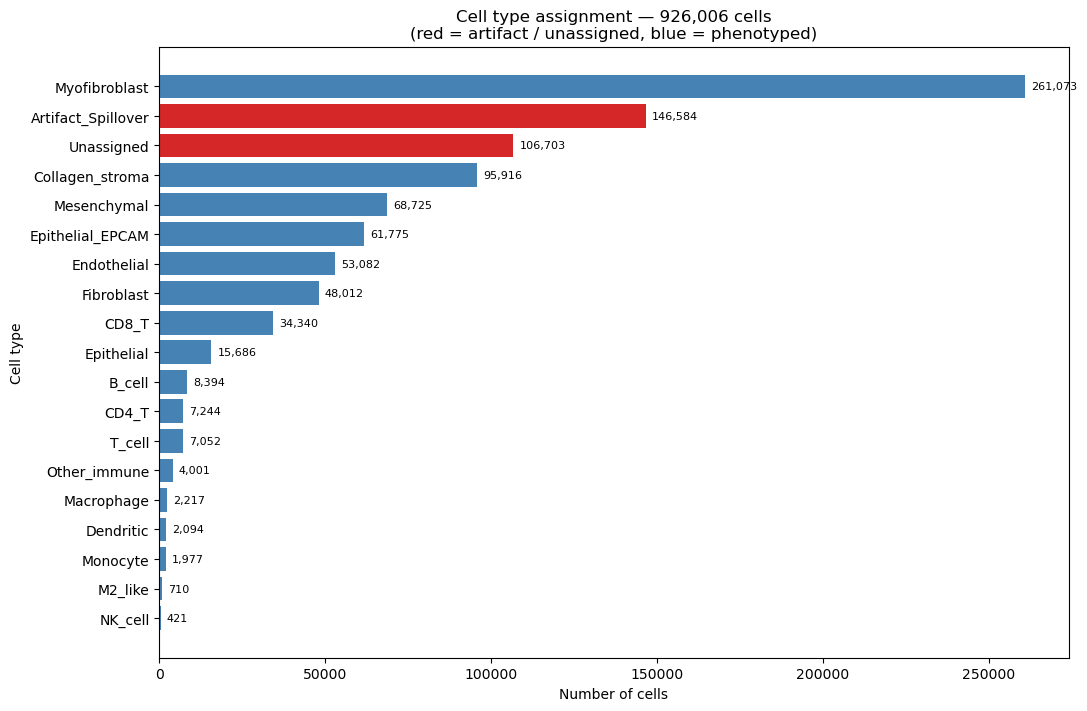

In [9]:
counts = adata.obs["cell_type"].value_counts().sort_values()

# Colour artifacts red, real cell types steelblue
colors = [
    "#d62728" if ct.startswith("Artifact_") or ct == "Unassigned"
    else "steelblue"
    for ct in counts.index
]

fig, ax = plt.subplots(figsize=(11, max(5, len(counts) * 0.38)))
bars = ax.barh(counts.index, counts.values, color=colors)
ax.set_xlabel("Number of cells")
ax.set_ylabel("Cell type")
ax.set_title(
    f"Cell type assignment — {len(adata):,} cells\n"
    f"(red = artifact / unassigned, blue = phenotyped)"
)
# Annotate bars with counts
for bar, v in zip(bars, counts.values):
    ax.text(bar.get_width() + len(adata) * 0.002, bar.get_y() + bar.get_height() / 2,
            f"{v:,}", va="center", ha="left", fontsize=8)
plt.tight_layout()
plt.show()

## 10. Save Annotated H5AD

The gating logic is encoded directly into `adata.uns` so the file is **self-documenting** — you
can reload it anywhere and know exactly how every label was produced without referring back to this notebook.

| Slot | Content |
|------|---------|
| `obs["cell_type"]` | Per-cell label (`CD8_T`, `Epithelial`, `Artifact_NoNucleus`, …) |
| `obs["qc_label"]` | QC status: `Pass` / `Artifact_NoNucleus` / `Artifact_Spillover` |
| `obs["is_clean"]` | Boolean: True = passed QC, False = artifact |
| `uns["cell_type_rules"]` | Dict `{cell_type → {positive: [...], negative: [...]}}` |
| `uns["qc_gates"]` | Nucleus marker, spillover pairs, EMT exception note |
| `uns["cell_type_counts"]` | Snapshot of counts at save time |

In [10]:
import json as _json

# ── Encode the gating logic into uns so the H5AD is self-documenting ─────────
# h5ad cannot serialise nested lists/dicts, so complex structures are stored as
# JSON strings and can be recovered with json.loads(adata.uns["cell_type_rules"]).

# 1. Cell-type rules: {name: {positive: [...], negative: [...]}}
adata.uns["cell_type_rules"] = _json.dumps({
    name: {"positive": pos, "negative": neg}
    for name, pos, neg in RULES
})

# 2. QC gate definitions
adata.uns["qc_gates"] = _json.dumps({
    "nucleus_check": "skipped — Cellpose DAPI mask defines cells",
    "spillover_pairs": [
        {"markers": [m1, m2], "reason": reason}
        for m1, m2, reason in SPILLOVER_GATES
        if m1 in marker_to_col and m2 in marker_to_col
    ],
    "emt_exception": "PANCK + VIM co-expression is NOT flagged (EMT tumour cells)",
})

# 3. Cell-type counts snapshot
adata.uns["cell_type_counts"] = _json.dumps(
    adata.obs["cell_type"].value_counts().to_dict()
)

# ── Save ──────────────────────────────────────────────────────────────────────
OUTPUT_H5AD = PROJECT_ROOT / "output" / "celldive_protein_matrix_celltypes.h5ad"
adata.write_h5ad(OUTPUT_H5AD)
print(f"Saved: {OUTPUT_H5AD}")
print(f"  obs : cell_type, qc_label, is_clean")
n_rules = len(_json.loads(adata.uns["cell_type_rules"]))
print(f"  uns : cell_type_rules ({n_rules} types, JSON str), qc_gates (JSON str), cell_type_counts (JSON str)")
print(f"  n_obs={adata.n_obs:,}  |  clean={int(is_clean.sum()):,}  |  artifacts={int((~is_clean).sum()):,}")


Saved: /home/steve/Projects/HeLab/BladderDIVE/output/celldive_protein_matrix_celltypes.h5ad
  obs : cell_type, qc_label, is_clean
  uns : cell_type_rules (17 types, JSON str), qc_gates (JSON str), cell_type_counts (JSON str)
  n_obs=926,006  |  clean=779,422  |  artifacts=146,584


## 10. Spatial plot (if coordinates available)

Scatter plot of cell centroids colored by cell type. For large datasets, subsample for speed.

## 11. Napari: full-resolution image + cell type overlay

Open Napari with the CellDIVE image and cell annotations. With `cells_per_type=True`, each cell type gets its own Labels layer (toggle on/off in the layer list). Use `display_mode="both"` to add centroid points too.

In [11]:
import sys
sys.path.insert(0, str(PROJECT_ROOT))

try:
    from scripts.napari_load_image_adata import open_napari_with_adata
    open_napari_with_adata(adata, color_column="cell_type", project_root=PROJECT_ROOT, display_mode="cells", cells_per_type=True)
    # open_napari_with_points(adata, color_column="cell_type", project_root=PROJECT_ROOT, display_mode="both", cells_per_type=True)
except (ImportError, ModuleNotFoundError):
    print("Skipping Napari (napari/dask not available in this environment — run interactively to launch viewer)")


Loaded Cellpose segmentation as Labels layer (multiscale pyramid, contour=1)
Loaded 19 cell-type layers (scale level 2)


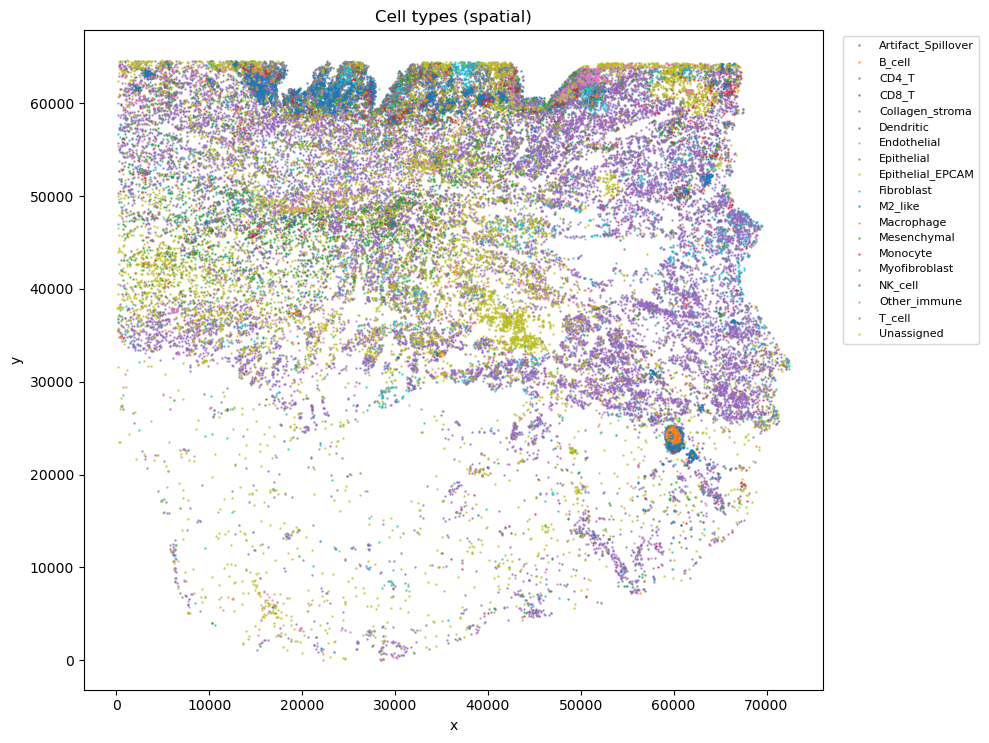

In [12]:
if "spatial" in adata.obsm:
    coords = adata.obsm["spatial"]
    # Subsample for plotting if > 50k cells
    n_plot = min(50000, len(adata))
    rng = np.random.default_rng(42)
    idx = rng.choice(len(adata), n_plot, replace=False)
    x, y = coords[idx, 0], coords[idx, 1]
    ct = adata.obs["cell_type"].values[idx]

    fig, ax = plt.subplots(figsize=(10, 10))
    for label in adata.obs["cell_type"].cat.categories:
        mask = ct == label
        if mask.sum() > 0:
            ax.scatter(x[mask], y[mask], s=0.5, label=label, alpha=0.7)
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_title("Cell types (spatial)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    ax.set_aspect("equal")
    plt.tight_layout()
    plt.show()
else:
    print("No obsm['spatial'] found. Skipping spatial plot.")